In [99]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [100]:
df = pd.read_csv('Salary_Data.csv')

In [101]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [103]:
df.shape

(6704, 6)

In [104]:
df.columns = ['Age', 'Gender', 'Degree', 'Job_Title', 'Experience_years', 'Salary']

In [105]:
df.describe()

,Age,Experience_years,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [106]:
df.duplicated().sum()

np.int64(4912)

In [107]:
df.drop_duplicates(inplace=True)

In [108]:
df.shape

(1792, 6)

In [109]:
df.isnull().sum()

Age                 1
Gender              1
Degree              2
Job_Title           1
Experience_years    2
Salary              4
dtype: int64

In [110]:
df.dropna(inplace=True)

In [111]:
df.shape

(1787, 6)

<Axes: >

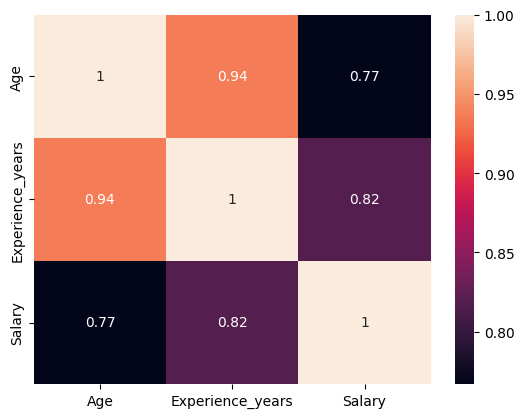

In [112]:
sns.heatmap(df[['Age', 'Experience_years', 'Salary']].corr(), annot=True)

<Axes: xlabel='Gender', ylabel='count'>

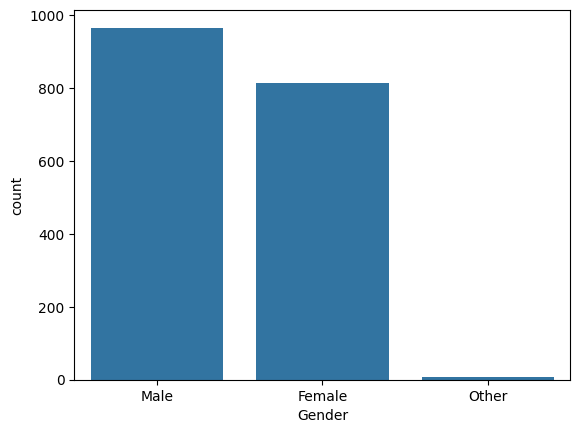

In [113]:
sns.countplot(x = df['Gender'])

In [114]:
df = df[df['Gender'] != 'Other']

<Axes: xlabel='Gender'>

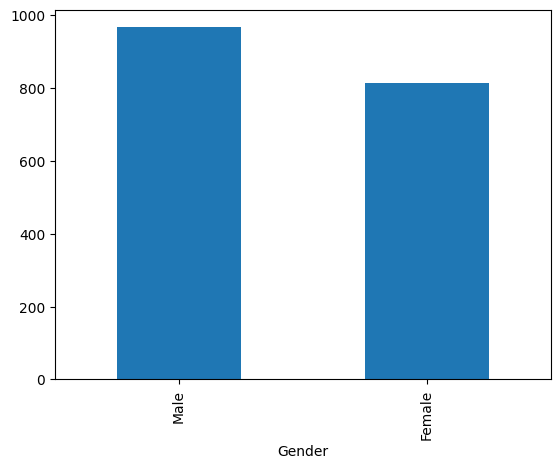

In [115]:
df["Gender"].value_counts().plot(kind = 'bar')

In [116]:
df["Gender"].value_counts()

Gender
Male      966
Female    814
Name: count, dtype: int64

In [117]:
 # df["Age"].plot(kind = 'hist')   

<Axes: xlabel='Age', ylabel='Count'>

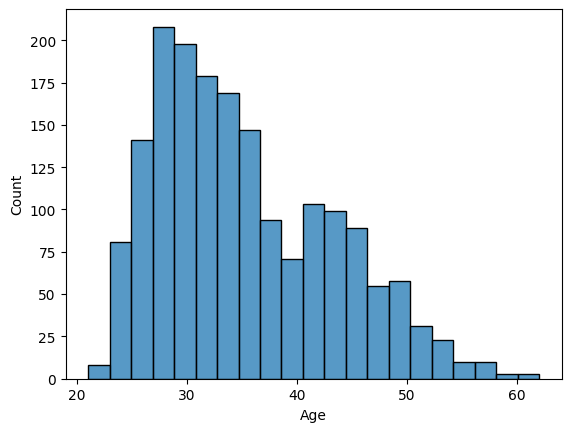

In [118]:
sns.histplot(x=df['Age'])

<Axes: >

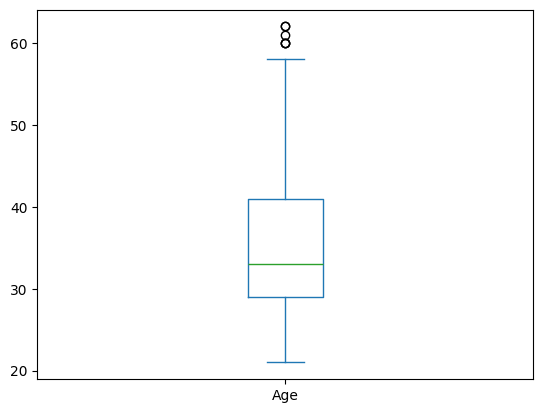

In [119]:
df["Age"].plot(kind = 'box')

In [120]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["Age"] >= Q1 - 1.5*IQR) & (df["Age"] <= Q3 + 1.5*IQR)]

<Axes: xlabel='Age'>

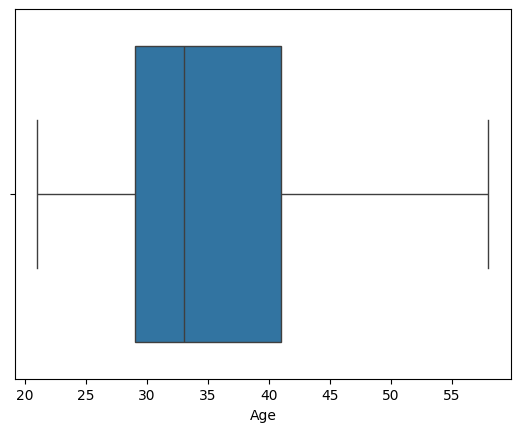

In [121]:
sns.boxplot(x=df['Age'] )

<Axes: xlabel='Salary'>

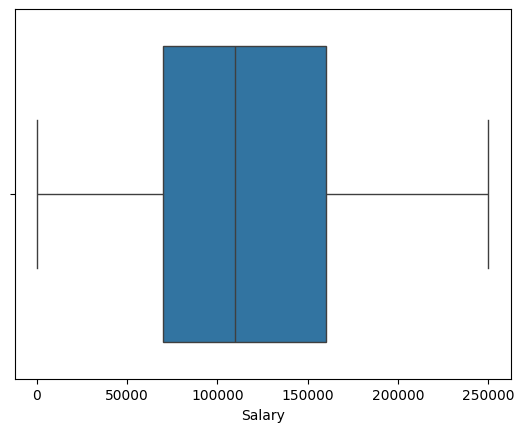

In [122]:
sns.boxplot(x=df['Salary'] )

In [123]:
# df["Salary"].plot(kind = 'hist')

<Axes: xlabel='Salary', ylabel='Count'>

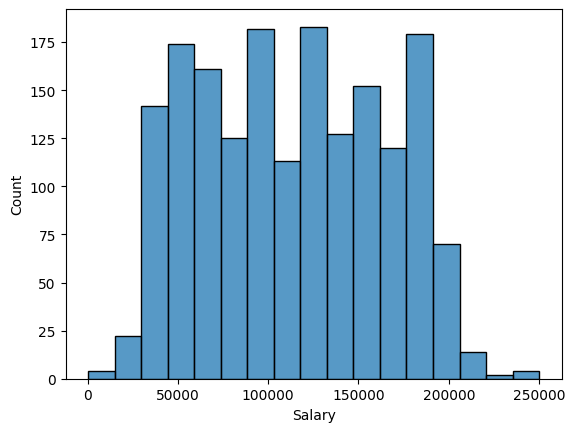

In [124]:
sns.histplot(x=df['Salary'])  

In [125]:
df.head()

,Age,Gender,Degree,Job_Title,Experience_years,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [126]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [127]:
df

,Age,Gender,Degree,Job_Title,Experience_years,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6623,43.0,Female,Master's Degree,Digital Marketing Manager,15.0,150000.0
6624,27.0,Male,High School,Sales Manager,2.0,40000.0
6625,33.0,Female,Bachelor's Degree,Director of Marketing,8.0,80000.0
6628,37.0,Male,Bachelor's Degree,Sales Director,7.0,90000.0


In [128]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [129]:
df['Gender_Encode'] = label_encoder.fit_transform(df['Gender'])

In [130]:
df['Degree_Encode'] = label_encoder.fit_transform(df['Degree'])

In [131]:
df['Job_Title_Encode'] = label_encoder.fit_transform(df['Job_Title'])

In [132]:
df.head()

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_Encode,Degree_Encode,Job_Title_Encode
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,175
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,3,18
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,5,144
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,115
4,52.0,Male,Master's,Director,20.0,200000.0,1,3,25


In [133]:
cols_to_drop = ['Gender', 'Degree', 'Job_Title']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [134]:
df.head()

,Age,Experience_years,Salary,Gender_Encode,Degree_Encode,Job_Title_Encode
0,32.0,5.0,90000.0,1,0,175
1,28.0,3.0,65000.0,0,3,18
2,45.0,15.0,150000.0,1,5,144
3,36.0,7.0,60000.0,0,0,115
4,52.0,20.0,200000.0,1,3,25


In [135]:
# X = df.drop(columns=['Salary'], axis=1)
X = df[['Age', 'Experience_years', 'Gender_Encode', 'Degree_Encode','Job_Title_Encode']]
y = df['Salary']

In [136]:
X.columns

Index(['Age', 'Experience_years', 'Gender_Encode', 'Degree_Encode',
       'Job_Title_Encode'],
      dtype='object')

In [137]:
# y.columns

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [141]:
from sklearn.linear_model import LinearRegression

In [142]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [143]:
y_pred = model.predict(X_test)

In [144]:
 # y_pred

In [145]:
y_test

2846    191510.0
1562     55000.0
3428    120000.0
284     100000.0
968     120000.0
          ...   
3896     45000.0
6279     55000.0
1480    140000.0
200     180000.0
15      125000.0
Name: Salary, Length: 355, dtype: float64

In [146]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [147]:
r2 = r2_score(y_test, y_pred)

In [148]:
r2

0.680111648953326

In [149]:
mae = mean_absolute_error(y_test, y_pred)

In [150]:
print('MAE',mae)

MAE 21939.85045368872


In [151]:
mse = mean_absolute_error(y_test, y_pred)

In [152]:
print('MSE', mse)

MSE 21939.85045368872


In [153]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

In [154]:
from sklearn.tree import DecisionTreeRegressor

In [155]:
model_DT = DecisionTreeRegressor(max_depth=3)

In [156]:

model_DT.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [157]:
y_pred_DT = model_DT.predict(X_test)

In [158]:
# y_pred_DT

In [159]:
r2 = r2_score(y_test, y_pred_DT)
mae = mean_absolute_error(y_test, y_pred_DT)
mse = mean_squared_error(y_test, y_pred_DT)

In [160]:
print("R2 Score : ", r2)
print("MAE : ", mae)
print("MSE : ", mse)

R2 Score :  0.6878247936599794
MAE :  21259.769749645096
MSE :  816651405.8048168


In [161]:
from sklearn.ensemble import RandomForestRegressor

In [162]:
rf = RandomForestRegressor(n_estimators=100, random_state= 42)

In [163]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [164]:
y_pred_rf = model_DT.predict(X_test)

In [165]:
# y_pred_rf

In [166]:
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)

In [167]:
print("R2 Score : ", r2)
print("MAE : ", mae)
print("MSE : ", mse)

R2 Score :  0.6878247936599794
MAE :  21259.769749645096
MSE :  816651405.8048168


In [185]:
from sklearn.model_selection import GridSearchCV

In [186]:
params = {
    "n_estimators" : [100, 200],
    "max_depth" : [None, 5 ,10]
}
grid = GridSearchCV(RandomForestRegressor(), params, cv=5)

In [187]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [100, 200]})

In [188]:
y_pred_gr = grid.predict(X_test)

In [189]:
r2 = r2_score(y_test, y_pred_gr)
mae = mean_absolute_error(y_test, y_pred_gr)
mse = mean_squared_error(y_test, y_pred_gr)

In [190]:
print("R2 Score : ", r2)
print("MAE : ", mae)
print("MSE : ", mse)

R2 Score :  0.8649131279944765
MAE :  11335.548893554254
MSE :  353387718.46258354


In [191]:
# model = RandomForestRegressor()

# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [5, 10]
# }

# grid = GridSearchCV(model, param_grid, cv=5, scoring='r2')

In [192]:
# grid.fit(X_train, y_train)

In [193]:
# y_pred_gr = grid.predict(X_test)

In [194]:
# r2 = r2_score(y_test, y_pred_gr)
# mae = mean_absolute_error(y_test, y_pred_gr)
# mse = mean_squared_error(y_test, y_pred_gr)

In [195]:
# print("R2 Score : ", r2)
# print("MAE : ", mae)
# print("MSE : ", mse)

In [1]:
# import joblib
# joblib.dump(grid, 'gridSCV_salPred.pkl')
# joblib.dump(scaler, 'scaler_sal.pkl')
# joblib.dump(X.columns.tolist(), 'columns.pkl')